# Rent Data Cleaning and EDA

This notebook cleans raw rental listings scraped from Madlan.

The goal is to create a clean dataset with these final columns:

- City
- Neighborhood
- price
- rooms
- price_per_room
- price_per_sqm

This cleaned dataset will later be used to compare rent prices across different cities in Israel.

In [ ]:
# Import libraries for data cleaning, analysis and visualization
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt

## 1. Project Settings

Here I define the city name and the output file name.

To reuse this notebook for another city, I only need to change these two variables.

In [ ]:
# Define the city name
CITY_NAME = "Tel Aviv"

# Define the output file name
OUTPUT_FILE = "tel_aviv_rent_clean.csv"

# Test that the variables are working
print("City selected:", CITY_NAME)
print("Output file:", OUTPUT_FILE)

City selected: Tel Aviv
Output file: tel_aviv_rent_clean.csv


## 2. Load Raw CSV Files

I uploaded several CSV files scraped from Madlan using a Chrome extension.

In this step, I combine all raw CSV files into one dataframe.

In [ ]:
# Find all CSV files uploaded to Colab
csv_files = glob.glob("*.csv")

# Display the list of files
csv_files

['TelAviv_rent5.csv',
 'TelAviv_rent3.csv',
 'TelAviv_rent6.csv',
 'TelAviv_rent4.csv',
 'TelAviv_rent2.csv',
 'TelAviv_rent1.csv',
 'TelAviv_rent7.csv',
 'tel_aviv_rent_clean.csv']

In [ ]:
# Create an empty list to store each CSV dataframe
raw_list = []

# Loop through every CSV file and read it
for file in csv_files:
    df = pd.read_csv(file)

    # Add the original file name for tracking
    df["original_file"] = file

    raw_list.append(df)

# Combine all CSV files into one dataframe
raw_rent = pd.concat(raw_list, ignore_index=True)

# Check the shape of the combined dataframe
raw_rent.shape

(625, 14)

In [ ]:
# Preview the first rows of the raw scraped data
raw_rent.head()

,css-u1nut8 href,css-hqth87,css-q8j3hw,css-q8j3hw 2,css-q8j3hw 3,css-n4p85g,css-afgd57,original_file,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,https://www.madlan.co.il/listings/erDzBKLODfs,"‏11,000 ‏₪",3 חד׳,קומה 1,"67 מ""ר","דירה, שוק 34, פלורנטין",NaN,TelAviv_rent5.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.madlan.co.il/listings/J6nPzA6StIs,"‏8,950 ‏₪",3 חד׳,קומה 3,"72 מ""ר","דירה, וולפסון 15, פלורנטין",NaN,TelAviv_rent5.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.madlan.co.il/listings/0FKweuBdpSy,"‏15,000 ‏₪",5 חד׳,קומה 9,"120 מ""ר","דירה, סלמה 46, פלורנטין",תיווך,TelAviv_rent5.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.madlan.co.il/listings/PdTB44YuSbd,"‏22,000 ‏₪",5 חד׳,קומה 22,"165 מ""ר","מיני פנטהאוז, פלורנטין",תיווך,TelAviv_rent5.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.madlan.co.il/listings/lC1wQNH6xbF,"‏7,500 ‏₪",2 חד׳,קומה 11,"47 מ""ר","דירה, דרך שלמה 46, פלורנטין",NaN,TelAviv_rent5.csv,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display all column names
raw_rent.columns

Index(['css-u1nut8 href', 'css-hqth87', 'css-q8j3hw', 'css-q8j3hw 2',
       'css-q8j3hw 3', 'css-n4p85g', 'css-afgd57', 'original_file', 'City',
       'Neighborhood', 'price', 'rooms', 'price_per_room', 'price_per_sqm'],
      dtype='object')

## 3. Select and Rename Useful Columns

The scraped data contains messy column names.

In this step, I select the columns that contain the important rental information and create a cleaner dataframe.

In [ ]:
# Create a clean dataframe
rent = pd.DataFrame()

# Add city name manually
rent["City"] = CITY_NAME

# Full raw location string
full_location = raw_rent["css-n4p85g"].astype(str)

# Extract address
rent["Address"] = (
    full_location
    .str.split(",")
    .str[0]
    .str.strip()
)

# Extract neighborhood
rent["Neighborhood"] = (
    full_location
    .str.split(",")
    .str[-1]
    .str.strip()
)

# Extract price
rent["price"] = raw_rent["css-hqth87"]

# Extract rooms
rent["rooms"] = raw_rent["css-q8j3hw"]

# Extract apartment size
rent["size_sqm"] = raw_rent["css-q8j3hw 3"]

# Preview dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,פלורנטין,"‏11,000 ‏₪",3 חד׳,"67 מ""ר"
1,NaN,דירה,פלורנטין,"‏8,950 ‏₪",3 חד׳,"72 מ""ר"
2,NaN,דירה,פלורנטין,"‏15,000 ‏₪",5 חד׳,"120 מ""ר"
3,NaN,מיני פנטהאוז,פלורנטין,"‏22,000 ‏₪",5 חד׳,"165 מ""ר"
4,NaN,דירה,פלורנטין,"‏7,500 ‏₪",2 חד׳,"47 מ""ר"


## 4. Clean Numeric Columns

The price, rooms and size columns may contain text, symbols or extra characters.

In this step, I extract only the numeric values and convert them into numeric data types.

In [ ]:
# Clean price column
rent["price"] = (
    rent["price"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Clean rooms column
rent["rooms"] = (
    rent["rooms"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Clean size_sqm column
rent["size_sqm"] = (
    rent["size_sqm"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Preview cleaned dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,פלורנטין,11000.0,3.0,67.0
1,NaN,דירה,פלורנטין,8950.0,3.0,72.0
2,NaN,דירה,פלורנטין,15000.0,5.0,120.0
3,NaN,מיני פנטהאוז,פלורנטין,22000.0,5.0,165.0
4,NaN,דירה,פלורנטין,7500.0,2.0,47.0


## 5. Clean Neighborhood Column

The neighborhood column may contain extra text.

In this step, I clean the neighborhood names and keep them as readable text.

In [ ]:
# Convert neighborhood column to string and clean extra spaces
rent["Neighborhood"] = (
    rent["Neighborhood"]
    .astype(str)
    .str.strip()
)

# Replace empty or invalid values with NaN
rent["Neighborhood"] = rent["Neighborhood"].replace(["nan", "", "None"], np.nan)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,פלורנטין,11000.0,3.0,67.0
1,NaN,דירה,פלורנטין,8950.0,3.0,72.0
2,NaN,דירה,פלורנטין,15000.0,5.0,120.0
3,NaN,מיני פנטהאוז,פלורנטין,22000.0,5.0,165.0
4,NaN,דירה,פלורנטין,7500.0,2.0,47.0


In [ ]:
# Translate neighborhood names to English

# Clean neighborhood column
rent["Neighborhood"] = rent["Neighborhood"].astype(str).str.strip()

# Dictionary with neighborhood translations
neighborhood_map = {

    "פלורנטין": "Florentin",
    "דרום פלורנטין": "South Florentin",

    "נוה שאנן": "Neve Shaanan",
    "נגה": "Noga",

    "נווה צדק": "Neve Tzedek",

    "דרום רוטשילד": "South Rothschild",

    "הצפון הישן החלק הדרום מערבי": "Old North Southwest",
    "הצפון הישן החלק הדרום מזרחי": "Old North Southeast",
    "הצפון הישן החלק הצפוני": "Old North North",
    "הצפון הישן החלק המרכזי": "Old North Central",

    "לב תל אביב": "Lev Tel Aviv",
    "לב תל אביב החלק המערבי": "Lev Tel Aviv West",

    "פרישמן": "Frishman",

    "הצפון החדש סביבת כיכר המדינה": "New North - Kikar HaMedina",
    "הצפון החדש החלק הצפוני": "New North North",
    "הצפון החדש החלק הדרומי": "New North South",

    "שרונה": "Sarona",
    "נחלת בנימין": "Nahalat Binyamin",
    "ביצרון": "Bitzaron",

    "שיכון עממי ג'": "Shikun Amami Gimel",

    "רמת אביב ג": "Ramat Aviv Gimel",

    "מרכז יפו": "Central Jaffa",

    "קרית שלום": "Kiryat Shalom",

    "שפירא": "Shapira",

    "שיכון בבלי": "Shikun Bavli",

    "דקר": "Dakar",

    "התקווה": "Hatikva",

    "תל חיים": "Tel Haim",

    "כרם התימנים": "Kerem HaTeimanim",

    "פארק צמרת": "Park Tzameret",

    "מע\"ר צפוני": "Northern Business District",

    "יד אליהו": "Yad Eliyahu",

    "נווה עופר": "Neve Ofer",

    "מונטיפיורי": "Montefiore",

    "תל ברוך צפון": "Tel Baruch North",

    "הדר יוסף": "Hadar Yosef",

    "עזרא והארגזים": "Ezra & HaArgazim",

    "נמל תל אביב": "Tel Aviv Port",

    "עג'מי": "Ajami"

}

# Replace Hebrew names with English names
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

# Preview translated neighborhoods
rent["Neighborhood"].unique()

array(['Florentin', 'South Florentin', 'Neve Shaanan', 'Neve Tzedek',
       'Noga', 'South Rothschild', 'Old North Southwest',
       'Lev Tel Aviv West', 'Frishman', 'Old North Southeast',
       'Old North Central', 'Old North North', 'Tel Aviv Port',
       'New North - Kikar HaMedina', 'Lev Tel Aviv', 'Sarona',
       'Nahalat Binyamin', 'Bitzaron', 'New North North',
       'Shikun Amami Gimel', 'New North South', 'Ramat Aviv Gimel',
       'Central Jaffa', 'Kiryat Shalom', 'Shapira', 'Shikun Bavli',
       'Dakar', 'Hatikva', 'Tel Haim', 'Kerem HaTeimanim',
       'Park Tzameret', 'Northern Business District', 'Yad Eliyahu',
       'Neve Ofer', 'Montefiore', 'Tel Baruch North', 'Hadar Yosef',
       'Ezra & HaArgazim', 'nan'], dtype=object)

In [ ]:
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

## 6. Remove Missing Values and Duplicates

In this step, I remove rows that do not have the essential information needed for analysis.

In [ ]:
# Check missing values
rent.isna().sum()

,0
City,625
Address,0
Neighborhood,0
price,279
rooms,299
size_sqm,287


In [ ]:
# Drop rows missing important columns
rent = rent.dropna(subset=["price", "rooms", "size_sqm"])

# Drop duplicated rows
rent = rent.drop_duplicates()

# Check the cleaned dataset shape
rent.shape

(278, 6)

## 7. Create KPI Columns

In this step, I create two important rent KPIs:

- price_per_room: how much each room costs on average
- price_per_sqm: how much each square meter costs on average

These metrics help compare apartments more fairly.

In [ ]:
# Calculate price per room
rent["price_per_room"] = rent["price"] / rent["rooms"]

# Calculate price per square meter
rent["price_per_sqm"] = rent["price"] / rent["size_sqm"]

# Round KPI columns
rent["price_per_room"] = rent["price_per_room"].round(2)
rent["price_per_sqm"] = rent["price_per_sqm"].round(2)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm,price_per_room,price_per_sqm
0,NaN,דירה,Florentin,11000.0,3.0,67.0,3666.67,164.18
1,NaN,דירה,Florentin,8950.0,3.0,72.0,2983.33,124.31
2,NaN,דירה,Florentin,15000.0,5.0,120.0,3000.00,125.00
3,NaN,מיני פנטהאוז,Florentin,22000.0,5.0,165.0,4400.00,133.33
4,NaN,דירה,Florentin,7500.0,2.0,47.0,3750.00,159.57


## 8. Keep Final Columns

Now I keep only the final columns needed for the project.

In [ ]:
# Dictionary to translate / standardize neighborhood names
neighborhood_map = {
    "פלורנטין": "Florentin",
    "יפו": "Jaffa",
    "נווה צדק": "Neve Tzedek",
    "לב תל אביב": "Lev Tel Aviv",
    "הצפון הישן": "Old North",
    "רמת אביב": "Ramat Aviv",
    "יד אליהו": "Yad Eliyahu",
    "כרם התימנים": "Kerem HaTeimanim",
    "שפירא": "Shapira",
    "בבלי": "Bavli",
    "נחלת יצחק": "Nahalat Yitzhak",
    "התקווה": "Hatikva",
    "מונטיפיורי": "Montefiore",
    "עג'מי": "Ajami",
    "נמל תל אביב": "Tel Aviv Port"
}

# Create translated neighborhood column
rent["Neighborhood_EN"] = rent["Neighborhood"].replace(neighborhood_map)

# Create final clean dataset
rent_final = rent[[
    "City",
    "Neighborhood_EN",
    "price",
    "rooms",
    "price_per_room",
    "price_per_sqm"
]]

# Rename translated column
rent_final = rent_final.rename(
    columns={"Neighborhood_EN": "Neighborhood"}
)

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,NaN,Florentin,11000.0,3.0,3666.67,164.18
1,NaN,Florentin,8950.0,3.0,2983.33,124.31
2,NaN,Florentin,15000.0,5.0,3000.00,125.00
3,NaN,Florentin,22000.0,5.0,4400.00,133.33
4,NaN,Florentin,7500.0,2.0,3750.00,159.57


In [ ]:
# Force city name into the final dataset
rent_final = rent_final.copy()

rent_final["City"] = "Tel Aviv"

# Reorder columns
rent_final = rent_final[
    ["City", "Neighborhood", "price", "rooms", "price_per_room", "price_per_sqm"]
]

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Tel Aviv,Florentin,11000.0,3.0,3666.67,164.18
1,Tel Aviv,Florentin,8950.0,3.0,2983.33,124.31
2,Tel Aviv,Florentin,15000.0,5.0,3000.00,125.00
3,Tel Aviv,Florentin,22000.0,5.0,4400.00,133.33
4,Tel Aviv,Florentin,7500.0,2.0,3750.00,159.57


## 9. Basic Dataset Quality Check

Before starting the analysis, I check the final dataset structure, missing values and summary statistics.

In [ ]:
# Dataset information
rent_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278 entries, 0 to 346
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            278 non-null    object 
 1   Neighborhood    278 non-null    object 
 2   price           278 non-null    float64
 3   rooms           278 non-null    float64
 4   price_per_room  278 non-null    float64
 5   price_per_sqm   278 non-null    float64
dtypes: float64(4), object(2)
memory usage: 23.3+ KB


In [ ]:
# Check missing values in final dataset
rent_final.isna().sum()

,0
City,0
Neighborhood,0
price,0
rooms,0
price_per_room,0
price_per_sqm,0


In [ ]:
# Summary statistics for numeric columns
rent_final.describe()

,price,rooms,price_per_room,price_per_sqm
count,278.000000,278.000000,278.000000,278.000000
mean,12789.744604,3.158273,3971.028885,139.699964
std,11842.165114,0.957652,2819.635030,43.719312
min,3950.000000,1.500000,1055.560000,53.120000
25%,7725.000000,2.500000,2930.000000,112.500000
50%,10500.000000,3.000000,3500.000000,135.000000
75%,14800.000000,4.000000,4333.330000,160.000000
max,175000.000000,9.000000,43750.000000,502.870000


## 10. Outlier Detection

Before calculating the final KPIs, I check for unrealistic rental prices that may distort the analysis.

Some listings may contain:
- data entry mistakes
- luxury penthouses
- incorrect listing types

These outliers can heavily affect averages and charts.

In [ ]:
# Display summary statistics for rent prices
rent_final["price"].describe()

,price
count,278.000000
mean,12789.744604
std,11842.165114
min,3950.000000
25%,7725.000000
50%,10500.000000
75%,14800.000000
max,175000.000000


In [ ]:
# Display the most expensive listings
rent_final.sort_values(by="price", ascending=False).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
67,Tel Aviv,Old North Southwest,175000.0,4.0,43750.00,502.87
326,Tel Aviv,New North North,42000.0,6.0,7000.00,190.91
289,Tel Aviv,Park Tzameret,40000.0,4.5,8888.89,200.00
241,Tel Aviv,Old North Southeast,40000.0,5.5,7272.73,166.67
42,Tel Aviv,Neve Tzedek,39000.0,4.0,9750.00,260.00
310,Tel Aviv,New North North,35000.0,6.0,5833.33,140.00
197,Tel Aviv,Lev Tel Aviv,35000.0,3.0,11666.67,243.06
91,Tel Aviv,Old North Southwest,35000.0,4.0,8750.00,280.00
74,Tel Aviv,Old North Southwest,32000.0,4.0,8000.00,256.00
44,Tel Aviv,Neve Tzedek,30000.0,5.0,6000.00,192.31


In [ ]:
# Display the cheapest listings
rent_final.sort_values(by="price", ascending=True).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
37,Tel Aviv,Neve Shaanan,3950.0,1.5,2633.33,106.76
45,Tel Aviv,Neve Shaanan,4000.0,2.0,2000.00,100.00
299,Tel Aviv,Ezra & HaArgazim,4200.0,2.0,2100.00,105.00
19,Tel Aviv,Florentin,4500.0,2.0,2250.00,112.50
36,Tel Aviv,Neve Shaanan,4650.0,2.0,2325.00,116.25
54,Tel Aviv,Old North Southwest,4800.0,1.5,3200.00,96.00
130,Tel Aviv,Old North North,4900.0,2.0,2450.00,98.00
204,Tel Aviv,Old North Southeast,4950.0,2.0,2475.00,99.00
32,Tel Aviv,South Florentin,5000.0,3.0,1666.67,76.92
196,Tel Aviv,Lev Tel Aviv,5200.0,2.0,2600.00,104.00


## 11. Outlier Filtering

Based on the initial data exploration, I remove unrealistic rental prices.

For this project, I keep listings between ₪3,000 and ₪50,000 per month.

This helps create more reliable KPIs and visualizations.

In [ ]:
# Remove unrealistic rental prices
rent_final = rent_final[
    (rent_final["price"] >= 3000) &
    (rent_final["price"] <= 50000)
].copy()

# Check updated dataset shape
rent_final.shape

(277, 6)

In [ ]:
# Check updated summary statistics
rent_final["price"].describe()

,price
count,277.000000
mean,12204.148014
std,6713.186660
min,3950.000000
25%,7700.000000
50%,10500.000000
75%,14500.000000
max,42000.000000


## 12. Neighborhood Sample Size

Some neighborhoods contain only a few rental listings.

Small samples may produce unreliable averages, so I check the number of listings per neighborhood before comparing them.

In [ ]:
# Count listings per neighborhood
neighborhood_counts = rent_final["Neighborhood"].value_counts()

# Display top neighborhoods by number of listings
neighborhood_counts.head(20)

,count
Neighborhood,
Lev Tel Aviv,39
Old North North,37
Old North Southeast,35
New North North,34
Old North Southwest,32
Florentin,28
Neve Shaanan,9
New North - Kikar HaMedina,9
Neve Tzedek,7


In [ ]:
# Keep only neighborhoods with at least 5 listings
valid_neighborhoods = neighborhood_counts[neighborhood_counts >= 5].index

# Filter dataset
rent_neighborhood_filtered = rent_final[
    rent_final["Neighborhood"].isin(valid_neighborhoods)
].copy()

# Check filtered dataset shape
rent_neighborhood_filtered.shape

(236, 6)

## 13. Main KPIs

In this section, I calculate the main rental KPIs for the city.

In [ ]:
# Main KPIs
average_rent = rent_final["price"].mean()
median_rent = rent_final["price"].median()
average_price_per_room = rent_final["price_per_room"].mean()
average_price_per_sqm = rent_final["price_per_sqm"].mean()
total_listings = len(rent_final)

print("City:", CITY_NAME)
print("Total listings:", total_listings)
print("Average rent:", round(average_rent, 2))
print("Median rent:", round(median_rent, 2))
print("Average price per room:", round(average_price_per_room, 2))
print("Average price per sqm:", round(average_price_per_sqm, 2))

City: Tel Aviv
Total listings: 277
Average rent: 12204.15
Median rent: 10500.0
Average price per room: 3827.42
Average price per sqm: 138.39


## 14. EDA - Rent Price Distribution

This chart shows how rent prices are distributed in the city.

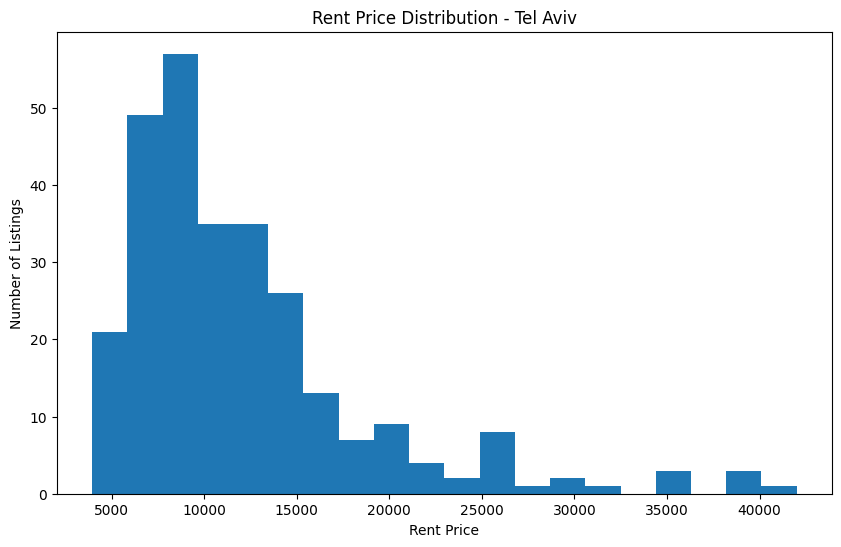

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(rent_final["price"], bins=20)

plt.title(f"Rent Price Distribution - {CITY_NAME}")
plt.xlabel("Rent Price")
plt.ylabel("Number of Listings")

plt.show()

## 15. EDA - Average Rent by Neighborhood

This analysis shows which neighborhoods have the highest average rent.

In [ ]:
avg_rent_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_rent_neighborhood.head(10)

,price
Neighborhood,
Neve Tzedek,19857.142857
New North North,16414.705882
New North - Kikar HaMedina,15355.555556
Old North Southwest,13425.000000
Old North Central,13366.666667
Lev Tel Aviv,12200.256410
Old North Southeast,11142.857143
Old North North,10912.135135
Florentin,8996.071429


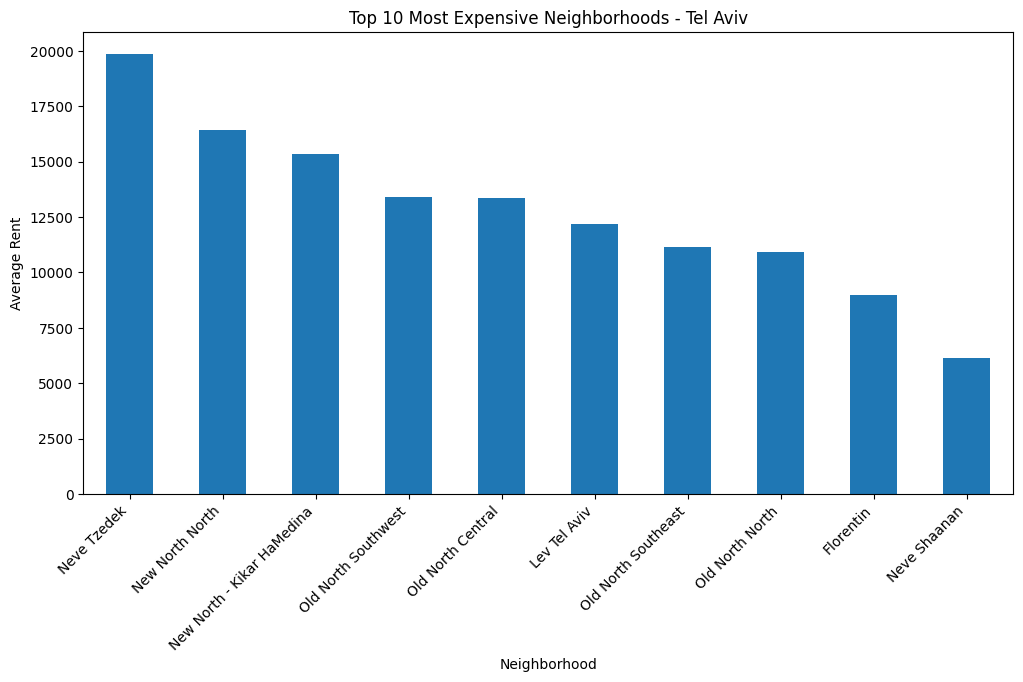

In [ ]:
top_neighborhoods = avg_rent_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Most Expensive Neighborhoods - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Rent")

plt.xticks(rotation=45, ha="right")
plt.show()

## 16. EDA - Cheapest Neighborhoods

This analysis shows the neighborhoods with the lowest average rent.

In [ ]:
cheapest_neighborhoods = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=True)
)

cheapest_neighborhoods.head(10)

,price
Neighborhood,
Neve Shaanan,6144.444444
Florentin,8996.071429
Old North North,10912.135135
Old North Southeast,11142.857143
Lev Tel Aviv,12200.256410
Old North Central,13366.666667
Old North Southwest,13425.000000
New North - Kikar HaMedina,15355.555556
New North North,16414.705882


## 17. EDA - Rooms vs Rent Price

This analysis checks how rent price changes depending on the number of rooms.

In [ ]:
avg_rent_by_rooms = (
    rent_final
    .groupby("rooms")["price"]
    .mean()
    .sort_values()
)

avg_rent_by_rooms

,price
rooms,
1.5,5108.000000
2.5,7616.666667
2.0,7829.072727
9.0,9500.000000
3.5,9900.000000
3.0,11385.377358
4.0,15748.813559
5.0,20064.285714
4.5,26996.000000


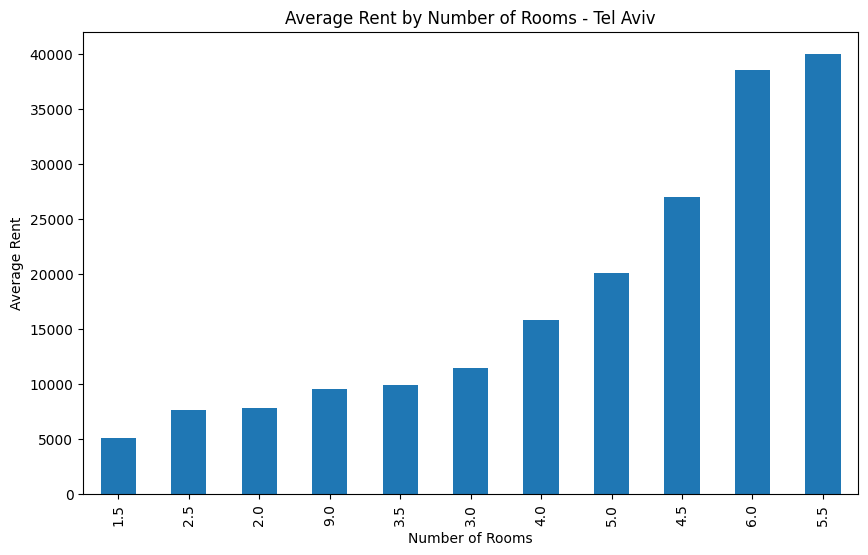

In [ ]:
plt.figure(figsize=(10, 6))
avg_rent_by_rooms.plot(kind="bar")

plt.title(f"Average Rent by Number of Rooms - {CITY_NAME}")
plt.xlabel("Number of Rooms")
plt.ylabel("Average Rent")

plt.show()

## 18. EDA - Price per Square Meter

Price per square meter is useful because it allows comparison between apartments of different sizes.

In [ ]:
avg_sqm_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price_per_sqm"]
    .mean()
    .sort_values(ascending=False)
)

avg_sqm_neighborhood.head(10)

,price_per_sqm
Neighborhood,
Neve Tzedek,185.962857
New North North,150.728529
Old North Southwest,148.416562
Old North North,143.035946
Lev Tel Aviv,142.384872
Old North Central,138.001667
Old North Southeast,135.856000
Florentin,129.365357
New North - Kikar HaMedina,119.525556


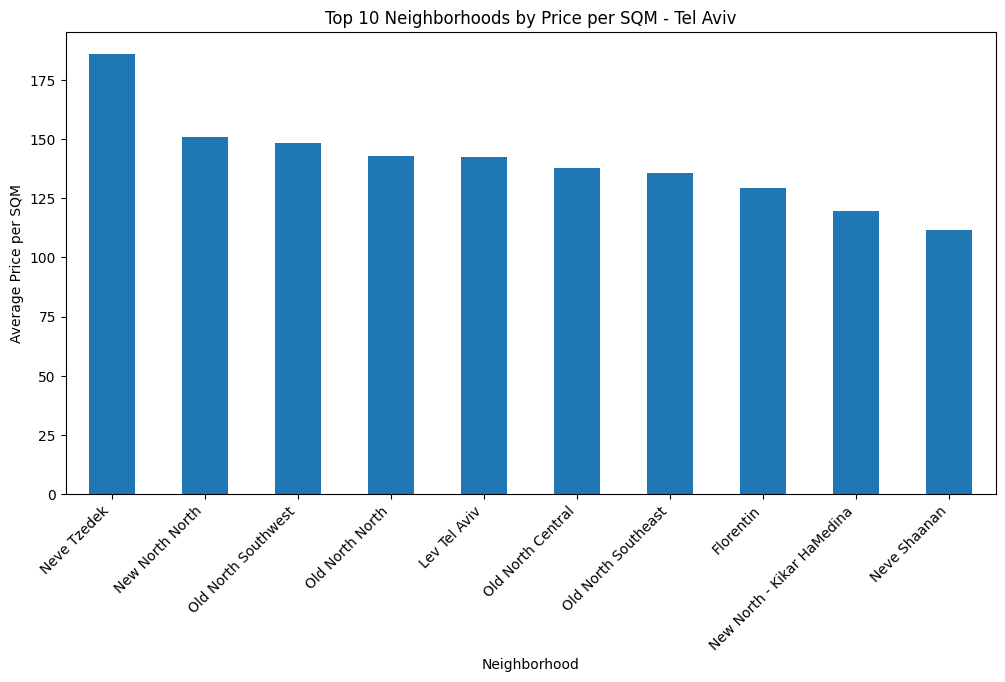

In [ ]:
top_sqm_neighborhoods = avg_sqm_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_sqm_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Neighborhoods by Price per SQM - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price per SQM")

plt.xticks(rotation=45, ha="right")
plt.show()

## 19. Export Clean Dataset

Finally, I export the cleaned dataset as a CSV file.

This file will later be combined with other city datasets.

In [ ]:
# Export final clean dataset
rent_final.to_csv(OUTPUT_FILE, index=False)

print(f"File exported successfully: {OUTPUT_FILE}")

File exported successfully: tel_aviv_rent_clean.csv


In [ ]:
from google.colab import files

files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>